# Flood AutoML — Balikpapan & Samarinda
**Notebook tunggal, self-contained — seluruh pipeline penelitian ada di sini.**

Memprediksi **kejadian banjir 3 hari ke depan** (`Flood_t+3`) dari data **cuaca + banjir**
yang ditransformasi jadi **time series** (lag `t-1..t-7` + akumulasi/rolling). Bila data
**DEM + RBI** tersedia, pipeline yang sama dipakai untuk membangun **peta probabilitas** banjir.

Sifat penelitian (untuk sidang): **data time series**, **target klasifikasi biner** banjir (0/1)
→ *Time Series Classification / Flood Forecasting Classification*, bukan forecasting nilai kontinu.

### Urutan sel
0. **Clone repository** — ambil semua kode + dataset dari GitHub (Colab).
1. **Pasang dependensi** — termasuk library geospasial (DEM/RBI).
2. **Import** — semua library di satu tempat.
3. **Upload ZIP DEM + RBI** (opsional) — hanya bila ingin jalur geospasial.
4. **Konfigurasi & deteksi MODE**.
5–14. Pipeline: bangun tabel → eksplorasi → preprocessing → imbalance → model+AutoML →
   evaluasi → output prediksi (kota+kecamatan) → feature importance → (geospasial) peta.

`MODE` otomatis: ada DEM+RBI → `geospatial`, jika tidak → `timeseries`.

## 0. Clone repository (Google Colab)
Mengambil seluruh kode + dataset (`processed/`, `clean/`, dll) dari GitHub sehingga notebook
tidak butuh file pendukung lain. **Ganti `REPO_URL`** dengan URL repo-mu. Data **DEM/RBI** tidak
ikut di repo (terlalu besar) — itu di-upload terpisah pada sel 3.

In [118]:
import os, sys, subprocess

REPO_URL = "https://github.com/Noelsip/flood-bpn-smd.git"   # <-- GANTI dengan URL repo GitHub-mu

def _in_colab():
    return "google.colab" in sys.modules

if _in_colab():
    repo_dir = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    if not os.path.isdir(repo_dir):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(repo_dir)
    print("Repo di-clone. Direktori kerja:", os.getcwd())
else:
    print("Bukan Colab: memakai file repo lokal (tidak perlu clone).")

Repo di-clone. Direktori kerja: /content/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd


## 1. Pasang dependensi (otomatis di Colab)
Memasang library inti **dan** geospasial (geopandas/rasterio) agar kedua mode siap.

In [119]:
if _in_colab():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numpy", "pandas", "scikit-learn", "xgboost", "catboost",
                    "flaml[automl]", "imbalanced-learn", "matplotlib",
                    "geopandas", "rasterio", "shapely", "pyproj", "scipy"], check=True)
    print("Dependensi (inti + geospasial) terpasang.")
else:
    print("Bukan Colab: pastikan requirements.txt sudah terpasang.")

Dependensi (inti + geospasial) terpasang.


## 2. Import (semua library di satu tempat)
Library inti selalu di-import; library geospasial (DEM/RBI) di-import dengan pengaman
(`HAS_GEO_LIBS`) supaya mode time series tetap jalan walau geopandas/rasterio belum ada.

In [120]:
import io, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from flaml import AutoML

warnings.filterwarnings("ignore")

# --- imbalance (opsional) ---
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except Exception:
    HAS_SMOTE = False

# --- geospasial DEM/RBI (opsional) ---
for _k in ("PROJ_LIB", "PROJ_DATA", "GDAL_DATA"):
    os.environ.pop(_k, None)
try:
    import pyproj
    os.environ["PROJ_LIB"] = pyproj.datadir.get_data_dir()
    import geopandas as gpd
    import rasterio
    from rasterio.transform import rowcol
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    from rasterio.features import rasterize
    from rasterio.mask import mask as rio_mask
    from scipy.ndimage import distance_transform_edt
    from shapely.geometry import Point, box
    HAS_GEO_LIBS = True
except Exception as _e:
    HAS_GEO_LIBS = False
    print("Library geospasial belum ada (mode geospatial nonaktif):", _e)

SEED = 42
np.random.seed(SEED)
print("Import OK | SMOTE:", HAS_SMOTE, "| geospasial:", HAS_GEO_LIBS)

Import OK | SMOTE: True | geospasial: True


## 3. Upload ZIP DEM + RBI (opsional, satu ZIP gabungan)
Hanya untuk **jalur geospasial**. Cukup **satu file ZIP** yang menggabungkan DEM dan RBI sekaligus,
dengan struktur folder dipertahankan:
```
dem/DEM SRTM 30M KALIMANTAN TIMUR.tif
RBI/KotaBalikpapan/RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/...
RBI/KotaSamarinda/RBI50K_KOTA SAMARINDA_KUGI50.gdb/...
padat-penduduk/
```
Jika nama file/folder berbeda, sesuaikan `DEM_PATH` / `CITIES` di **Sel 4**.
Lewati sel ini bila hanya menjalankan mode time series (cuaca + banjir).

In [121]:
!apt-get update -qq
!apt-get install -y p7zip-full

from google.colab import files
import os

print("Pilih ZIP DEM/RBI...")
uploaded = files.upload()

for fname in uploaded:

    if fname.lower().endswith(".zip"):

        print(f"\nMengekstrak {fname} ...")

        result = os.system(f'7z x "{fname}" -y')

        if result == 0:
            print("✓ Berhasil")
        else:
            print("✗ Gagal")

print("\nIsi folder saat ini:")
!find . -maxdepth 3

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Pilih ZIP DEM/RBI...


Saving geospecial.zip to geospecial.zip

Mengekstrak geospecial.zip ...
✓ Berhasil

Isi folder saat ini:
.
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a000001ac.spx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000073.spx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a0000019e.gdbtablx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a0000019e.spx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000067.gdbtable
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a0000003b.gdbtablx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a000001be.gdbtablx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000033.freelist
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a000001bd.freelist
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000070.freelist
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a0000016a.gdbtablx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a0000002e.gdbtable
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000010.gdbindexes
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a0000001d.gdbtable
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000019.gdbtablx
./RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/a00000057

## 4. Konfigurasi & deteksi MODE

In [122]:
def find_root(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "processed").exists() or (c / "clean").exists() or (c / "dem").exists():
            return c
    return start

BASE_DIR = find_root(Path.cwd())
OUT_DIR = BASE_DIR / "outputs"; OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON, LAGS = 3, 7              # prediksi Flood_t+3, jendela lag t-1..t-7
TIME_BUDGET = 120                 # detik untuk AutoML FLAML
UTM_CRS, WGS84 = "EPSG:32750", "EPSG:4326"
DEM_PATH = BASE_DIR / "dem" / "DEM SRTM 30M KALIMANTAN TIMUR.tif"
CLEAN_DIR = BASE_DIR / "clean"; ADMIN_DIR = CLEAN_DIR / "admin"
CITIES = {
    "Balikpapan": dict(
        gdb=BASE_DIR / "RBI" / "KotaBalikpapan" / "RBI50K_KOTA BALIKPAPAN_KUGI50.gdb",
        banjir=CLEAN_DIR / "banjir_balikpapan.csv", penduduk=CLEAN_DIR / "penduduk_balikpapan.csv",
        admin_kec=ADMIN_DIR / "balikpapan_kecamatan.geojson", admin_kel=ADMIN_DIR / "balikpapan_kelurahan.geojson"),
    "Samarinda": dict(
        gdb=BASE_DIR / "RBI" / "KotaSamarinda" / "RBI50K_KOTA SAMARINDA_KUGI50.gdb",
        banjir=CLEAN_DIR / "banjir_samarinda.csv", penduduk=CLEAN_DIR / "penduduk_samarinda.csv",
        admin_kec=ADMIN_DIR / "samarinda_kecamatan.geojson", admin_kel=ADMIN_DIR / "samarinda_kelurahan.geojson"),
}
ADMIN_KEC_NAMECOL, ADMIN_KEL_NAMECOL = "WADMKC", "WADMKD"
L_RIVER, L_ROAD, L_LANDCOVER, LC_CLASS_COL = "SUNGAI_LN_50K", "JALAN_LN_50K", "PENUTUPLAHAN_AR_50K", "REMARK"
POINTS_PER_EVENT, FLOOD_ELEV_QUANTILE, NONFLOOD_ELEV_QUANTILE, NONFLOOD_MIN_DIST = 8, 0.40, 0.50, 750.0
GEO_NUM = ["elevation", "slope", "dist_river", "dist_road", "pop_density"]

def geo_ready():
    if not HAS_GEO_LIBS or not DEM_PATH.exists():
        return False
    for cfg in CITIES.values():
        if not all(Path(cfg[k]).exists() for k in ("gdb", "admin_kec", "admin_kel", "banjir", "penduduk")):
            return False
    return True

MODE = "geospatial" if geo_ready() else "timeseries"
print("Root proyek:", BASE_DIR)
print("MODE:", MODE, "| SMOTE:", HAS_SMOTE, "| geospasial:", HAS_GEO_LIBS)

Root proyek: /content/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd
MODE: timeseries | SMOTE: True | geospasial: True


## 5. Fungsi pembangun tabel model
Dua sumber, satu keluaran seragam `(data, info)` sehingga pipeline setelahnya identik.

**A. Time series** — transformasi cuaca harian jadi lag `t-1..t-7` + akumulasi (hujan 3/7/14 hari,
dst) dan target `Flood_t+3`. Memakai `dataset_timeseries.csv` bila ada; jika tidak, dibangun dari
`dataset_utama.csv`. `latitude`/`longitude` tidak ditransformasi — dipakai apa adanya sebagai info
lokasi dan dibawa ke output prediksi.

In [123]:
WEATHER_COLS = {
    "precipitation_sum (mm)": "precip", "temperature_2m_max (\u00b0C)": "tmax",
    "temperature_2m_min (\u00b0C)": "tmin", "wind_speed_10m_max (km/h)": "wind",
    "rain_sum (mm)": "rain", "soil_moisture_0_to_100cm_mean (m\u00b3/m\u00b3)": "soil",
}

def _build_ts_from_primary(prim_path):
    df = pd.read_csv(prim_path)
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.rename(columns=WEATHER_COLS).sort_values(["city", "time"]).reset_index(drop=True)
    df["month"], df["dayofyear"] = df["time"].dt.month, df["time"].dt.dayofyear
    g = df.groupby("city", sort=False)
    short = list(WEATHER_COLS.values())
    for col in short:
        for k in range(1, LAGS + 1):
            df[f"{col}_lag{k}"] = g[col].shift(k)
    def roll(col, w, how):
        s = g[col].shift(1).rolling(w, min_periods=w)
        return s.sum() if how == "sum" else s.mean()
    df["rain_roll3_sum"], df["rain_roll7_sum"], df["rain_roll14_sum"] = roll("rain", 3, "sum"), roll("rain", 7, "sum"), roll("rain", 14, "sum")
    df["precip_roll3_sum"], df["precip_roll7_sum"] = roll("precip", 3, "sum"), roll("precip", 7, "sum")
    df["soil_roll3_mean"], df["soil_roll7_mean"], df["tmax_roll7_mean"] = roll("soil", 3, "mean"), roll("soil", 7, "mean"), roll("tmax", 7, "mean")
    df[f"Flood_t+{HORIZON}"] = g["Flood"].shift(-HORIZON)
    # latitude/longitude dibiarkan apa adanya (info lokasi, bukan fitur yang di-scale).
    lag_roll = [c for c in df.columns if any(c.endswith(s) for s in [f"_lag{k}" for k in range(1, LAGS + 1)]) or c.endswith(("_sum", "_mean"))]
    df = df.dropna(subset=lag_roll + [f"Flood_t+{HORIZON}"]).reset_index(drop=True)
    df[f"Flood_t+{HORIZON}"] = df[f"Flood_t+{HORIZON}"].astype(int)
    return df

def build_timeseries_table():
    TARGET = f"Flood_t+{HORIZON}"
    ts = BASE_DIR / "processed" / "dataset_timeseries.csv"
    prim = BASE_DIR / "processed" / "dataset_utama.csv"
    if ts.exists():
        df = pd.read_csv(ts, parse_dates=["time"])
        print("Sumber: dataset_timeseries.csv")
    elif prim.exists():
        df = _build_ts_from_primary(prim)
        print("Sumber: dataset_utama.csv (ditransformasi inline)")
    else:
        raise FileNotFoundError("Tidak ada dataset_timeseries.csv / dataset_utama.csv. Upload ZIP dataset dulu (sel 1).")
    df = df.sort_values(["time", "city"]).reset_index(drop=True)
    drop_cols = {"location_id", "latitude", "longitude", "time", "Flood", TARGET}
    cat_cols = [c for c in ["city"] if c in df.columns]
    num_cols = [c for c in df.columns if c not in drop_cols and c not in cat_cols and pd.api.types.is_numeric_dtype(df[c])]
    id_cols = [c for c in ["time", "city", "latitude", "longitude"] if c in df.columns]
    info = dict(mode="timeseries", target=TARGET, num_cols=num_cols, cat_cols=cat_cols,
               id_cols=id_cols, split="time", time_col="time", automl_metric="ap")
    return df, info
print("Fungsi time series siap.")

Fungsi time series siap.


**B. Geospasial (DEM + RBI)** — bangun titik *terrain-constrained* (banjir di zona elevasi rendah
per kecamatan terdampak) + 6 conditioning factor. Library geospasial diimpor di sini agar mode
time series tidak membutuhkannya.

In [124]:
CITY_LAYERS, LC_MAP = {}, {}

def build_geospatial_table():
    global CITY_LAYERS, LC_MAP
    # library geospasial sudah di-import di sel 2 (gpd, rasterio, rowcol, rasterize, dll).
    def _norm(s): return str(s).strip().lower()
    def read_gdb(gdb, layer):
        g = gpd.read_file(gdb, layer=layer); return (g.set_crs(WGS84) if g.crs is None else g).to_crs(UTM_CRS)
    def load_admin(path, col):
        g = gpd.read_file(path)
        if col not in g.columns:
            raise KeyError(f"Kolom {col!r} tidak ada di {Path(path).name}. Kolom: {list(g.columns)}")
        g = (g.set_crs(WGS84) if g.crs is None else g).to_crs(UTM_CRS).copy(); g["adm_name"] = g[col]; return g
    def clip_dem(boundary_wgs, pad=0.02):
        minx, miny, maxx, maxy = boundary_wgs.bounds; bb = box(minx-pad, miny-pad, maxx+pad, maxy+pad)
        with rasterio.open(DEM_PATH) as src:
            arr, tr = rio_mask(src, [bb], crop=True)
            t2, w2, h2 = calculate_default_transform(src.crs, UTM_CRS, arr.shape[2], arr.shape[1],
                *rasterio.transform.array_bounds(arr.shape[1], arr.shape[2], tr))
            dst = np.full((h2, w2), np.nan, dtype="float32")
            reproject(arr[0], dst, src_transform=tr, src_crs=src.crs, dst_transform=t2, dst_crs=UTM_CRS,
                      resampling=Resampling.bilinear, src_nodata=src.nodata, dst_nodata=np.nan)
        return dst.astype(float), t2
    def slope_deg(dem, tr):
        dzdy, dzdx = np.gradient(dem, abs(tr.e), abs(tr.a)); return np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))
    def sample_at(points, arr, tr):
        out = []
        for geom in points.geometry:
            r, c = rowcol(tr, geom.x, geom.y)
            out.append(arr[r, c] if (0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]) else np.nan)
        return np.array(out, dtype=float)
    def attach_poly(points, poly, col):
        j = gpd.sjoin(points, poly[["geometry", col]], how="left", predicate="within")
        return j[~j.index.duplicated(keep="first")].loc[points.index, col].values
    def flood_pts_in_kec(poly, n, dem, tr, q, rng):
        H, W = dem.shape
        m = rasterize([(poly, 1)], out_shape=(H, W), transform=tr, fill=0, all_touched=True).astype(bool)
        cells = m & np.isfinite(dem)
        if cells.sum() == 0: return []
        thr = np.nanquantile(dem[cells], q); low = cells & (dem <= thr)
        rows, cols = np.where(low if low.sum() >= n else cells)
        if len(rows) == 0: return []
        idx = rng.choice(len(rows), size=min(n, len(rows)), replace=len(rows) < n)
        return [Point(*rasterio.transform.xy(tr, rows[k], cols[k])) for k in idx]
    def nonflood_pts(flood_gdf, dem, tr, n, q, min_dist, rng):
        minx, miny, maxx, maxy = flood_gdf.total_bounds; pad = 0.15 * max(maxx-minx, maxy-miny)
        minx, miny, maxx, maxy = minx-pad, miny-pad, maxx+pad, maxy+pad
        thr = np.nanquantile(dem, q); uni = flood_gdf.unary_union; pts, t = [], 0
        while len(pts) < n and t < n*400:
            t += 1; px, py = rng.uniform(minx, maxx), rng.uniform(miny, maxy); r, c = rowcol(tr, px, py)
            if not (0 <= r < dem.shape[0] and 0 <= c < dem.shape[1]): continue
            if not np.isfinite(dem[r, c]) or dem[r, c] < thr: continue
            p = Point(px, py)
            if p.distance(uni) < min_dist: continue
            pts.append(p)
        return gpd.GeoDataFrame(geometry=pts, crs=UTM_CRS)

    dfs = {}
    for name, cfg in CITIES.items():
        print("==", name, "=="); rng = np.random.default_rng(SEED)
        kec = load_admin(cfg["admin_kec"], ADMIN_KEC_NAMECOL); desakel = load_admin(cfg["admin_kel"], ADMIN_KEL_NAMECOL)
        bnd = kec.dissolve().geometry.iloc[0]; bnd_wgs = gpd.GeoSeries([bnd], crs=UTM_CRS).to_crs(WGS84).iloc[0]
        dem, tr = clip_dem(bnd_wgs); slope = slope_deg(dem, tr)
        rivers = read_gdb(cfg["gdb"], L_RIVER); rivers = rivers[rivers.intersects(bnd)]
        roads = read_gdb(cfg["gdb"], L_ROAD); roads = roads[roads.intersects(bnd)]
        landcover = read_gdb(cfg["gdb"], L_LANDCOVER); landcover = landcover[landcover.intersects(bnd)]
        pen = pd.read_csv(cfg["penduduk"]); pen["_k"] = pen["kelurahan"].map(_norm)
        desakel["_k"] = desakel["adm_name"].map(_norm); desakel["area_km2"] = desakel.geometry.area / 1e6
        desakel = desakel.merge(pen[["_k", "value", "value_type"]].drop_duplicates("_k"), on="_k", how="left")
        desakel["pop_density"] = np.where(desakel["value_type"].eq("count"), desakel["value"]/desakel["area_km2"], desakel["value"])
        kec["_k"] = kec["adm_name"].map(_norm); bj = pd.read_csv(cfg["banjir"]); bj["_k"] = bj["kecamatan"].map(_norm)
        kec = kec.merge(bj[["_k", "banjir_count"]], on="_k", how="left")
        fpts = []
        for _, row in kec.iterrows():
            cnt = row["banjir_count"]
            if pd.isna(cnt) or cnt <= 0: continue
            fpts += flood_pts_in_kec(row.geometry, int(round(cnt))*POINTS_PER_EVENT, dem, tr, FLOOD_ELEV_QUANTILE, rng)
        fg = gpd.GeoDataFrame(geometry=fpts, crs=UTM_CRS)
        ng = nonflood_pts(fg, dem, tr, len(fg), NONFLOOD_ELEV_QUANTILE, NONFLOOD_MIN_DIST, rng)
        fg["label"], ng["label"] = 1, 0
        pts = gpd.GeoDataFrame(pd.concat([fg[["geometry", "label"]], ng[["geometry", "label"]]], ignore_index=True), geometry="geometry", crs=UTM_CRS)
        ru, rdu = rivers.unary_union, roads.unary_union
        pts["elevation"], pts["slope"] = sample_at(pts, dem, tr), sample_at(pts, slope, tr)
        pts["dist_river"] = pts.geometry.apply(lambda g: g.distance(ru))
        pts["dist_road"] = pts.geometry.apply(lambda g: g.distance(rdu))
        pts["landcover_raw"] = [str(v) for v in attach_poly(pts, landcover, LC_CLASS_COL)]
        pts["pop_density"] = attach_poly(pts, desakel, "pop_density"); pts["city"] = name
        out = pd.DataFrame(pts.drop(columns="geometry")); out["x"], out["y"] = pts.geometry.x.values, pts.geometry.y.values
        dfs[name] = out
        CITY_LAYERS[name] = dict(dem=dem, slope=slope, transform=tr, rivers=rivers, roads=roads, landcover=landcover, desakel=desakel)
    df = pd.concat(dfs.values(), ignore_index=True)
    classes = sorted(df["landcover_raw"].dropna().unique().tolist()); LC_MAP = {c: i for i, c in enumerate(classes)}
    df["landcover"] = df["landcover_raw"].map(LC_MAP).fillna(-1).astype(int)
    info = dict(mode="geospatial", target="label", num_cols=GEO_NUM, cat_cols=["landcover"],
               id_cols=[c for c in ["city", "x", "y"] if c in df.columns],
               split="stratified", time_col=None, automl_metric="roc_auc")
    return df, info
print("Fungsi geospasial siap.")

Fungsi geospasial siap.


## 6. Jalankan proses (satu sel) — bangun tabel model
Memilih sumber otomatis sesuai `MODE`, lalu menghasilkan `data` + `info`. Pipeline di bawahnya identik.

In [125]:
if MODE == "timeseries":
    data, info = build_timeseries_table()
else:
    data, info = build_geospatial_table()

TARGET = info["target"]
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=info["num_cols"] + info["cat_cols"] + [TARGET]).reset_index(drop=True)
print(f"\nMODE={info['mode']} | tabel model: {data.shape} | target: {TARGET} | split: {info['split']}")
print(f"Fitur: {len(info['num_cols'])} numerik + {len(info['cat_cols'])} kategori")
pos = int(data[TARGET].sum())
print(f"Positif (banjir): {pos}/{len(data)} ({pos/len(data)*100:.2f}%)")
display(data.head(3))

Sumber: dataset_timeseries.csv

MODE=timeseries | tabel model: (6418, 65) | target: Flood_t+3 | split: time
Fitur: 58 numerik + 1 kategori
Positif (banjir): 54/6418 (0.84%)


,city,location_id,latitude,longitude,time,precip,tmax,tmin,wind,rain,...,soil_lag7,rain_roll3_sum,rain_roll7_sum,rain_roll14_sum,precip_roll3_sum,precip_roll7_sum,soil_roll3_mean,soil_roll7_mean,tmax_roll7_mean,Flood_t+3
0,Kota Balikpapan,0,-1.230228,116.85083,2016-07-27,9.1,26.8,22.9,9.5,9.1,...,0.389,33.5,85.0,130.6,33.5,85.0,0.419667,0.410429,26.900000,0
1,Kota Samarinda,1,-0.527241,117.13390,2016-07-27,17.2,27.7,22.9,7.8,17.2,...,0.410,35.2,84.0,152.9,35.2,84.0,0.424333,0.420286,28.042857,0
2,Kota Balikpapan,0,-1.230228,116.85083,2016-07-28,9.9,27.2,23.0,11.8,9.9,...,0.399,34.9,82.2,135.4,34.9,82.2,0.424000,0.416000,26.842857,0


## 7. Eksplorasi singkat

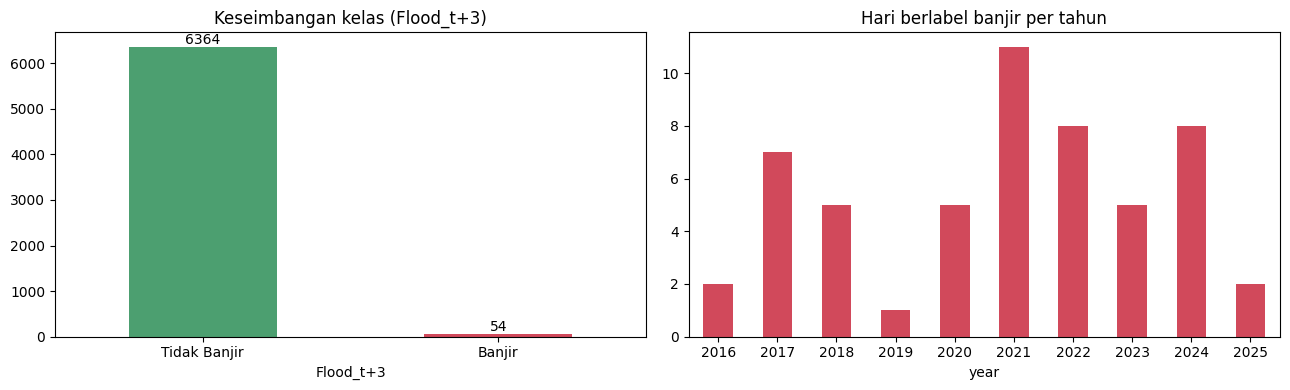

== Banjir historis per kecamatan — Balikpapan (BPS) ==
           kota          kecamatan  banjir_count
Kota Balikpapan Balikpapan Selatan             6
Kota Balikpapan   Balikpapan Timur             4
Kota Balikpapan  Balikpapan Tengah             4
Kota Balikpapan    Balikpapan Kota             2
Kota Balikpapan   Balikpapan Utara             2
Kota Balikpapan   Balikpapan Barat             2
== Banjir historis per kecamatan — Samarinda (BPS) ==
          kota          kecamatan  banjir_count
Kota Samarinda      Samarinda Ulu             8
Kota Samarinda    Samarinda Utara             8
Kota Samarinda     Sungai Kunjang             7
Kota Samarinda            Palaran             5
Kota Samarinda     Samarinda Ilir             5
Kota Samarinda     Loa Janan Ilir             5
Kota Samarinda     Samarinda Kota             4
Kota Samarinda           Sambutan             4
Kota Samarinda      Sungai Pinang             4
Kota Samarinda Samarinda Seberang             3


In [126]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vc = data[TARGET].value_counts().sort_index()
vc.rename({0: "Tidak Banjir", 1: "Banjir"}).plot(kind="bar", ax=ax[0], color=["#4C9F70", "#D1495B"])
ax[0].set_title(f"Keseimbangan kelas ({TARGET})"); ax[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(vc.values):
    ax[0].text(i, v, str(v), ha="center", va="bottom")

if info["time_col"] and info["time_col"] in data.columns:
    data[data[TARGET] == 1].assign(year=data[info["time_col"]].dt.year).groupby("year").size().plot(
        kind="bar", ax=ax[1], color="#D1495B"); ax[1].set_title("Hari berlabel banjir per tahun")
else:
    data.groupby("city")[TARGET].mean().plot(kind="bar", ax=ax[1], color="#D1495B"); ax[1].set_title("Proporsi banjir per kota")
ax[1].tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()

# Konteks wilayah (dipakai untuk OUTPUT kecamatan di mode time series).
for nm, fn in [("Balikpapan", "clean/banjir_balikpapan.csv"), ("Samarinda", "clean/banjir_samarinda.csv")]:
    p = BASE_DIR / fn
    if p.exists():
        print(f"== Banjir historis per kecamatan — {nm} (BPS) ==")
        print(pd.read_csv(p).sort_values("banjir_count", ascending=False).to_string(index=False))

## 8. Preprocessing & split
Split **berbasis waktu** untuk time series (anti-leakage), **stratified** untuk geospasial.
Scaler & encoder di-fit **hanya pada data latih**.

In [127]:
num_cols, cat_cols = info["num_cols"], info["cat_cols"]
if info["split"] == "time":
    ordered = data.sort_values(info["time_col"]).reset_index(drop=True)
    cut = int(len(ordered) * 0.70)
    train_df, test_df = ordered.iloc[:cut].copy(), ordered.iloc[cut:].copy()
else:
    train_df, test_df = train_test_split(data, test_size=0.30, stratify=data[TARGET], random_state=SEED)
train_df = train_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)

scaler = StandardScaler().fit(train_df[num_cols])
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(train_df[cat_cols]) if cat_cols else None
def transform(frame):
    parts = [pd.DataFrame(scaler.transform(frame[num_cols]), columns=num_cols, index=frame.index)]
    if encoder is not None:
        parts.append(pd.DataFrame(encoder.transform(frame[cat_cols]), columns=cat_cols, index=frame.index))
    return pd.concat(parts, axis=1)

X_train = transform(train_df).reset_index(drop=True); X_test = transform(test_df).reset_index(drop=True)
y_train = train_df[TARGET].astype(int).reset_index(drop=True); y_test = test_df[TARGET].astype(int).reset_index(drop=True)
print("Split:", info["split"], "| Train:", X_train.shape, "| Test:", X_test.shape)
print("Banjir train:", int(y_train.sum()), "| test:", int(y_test.sum()))

Split: time | Train: (4492, 59) | Test: (1926, 59)
Banjir train: 38 | test: 16


## 9. Penanganan imbalance — hanya pada data latih

In [128]:
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
spw = neg / max(pos, 1)
if HAS_SMOTE and pos >= 6:
    k = min(5, pos - 1)
    X_fit, y_fit = SMOTE(random_state=SEED, k_neighbors=k).fit_resample(X_train, y_train)
    method, spw_model = f"SMOTE (k={k})", 1.0
else:
    X_fit, y_fit, method, spw_model = X_train, y_train, "class_weight", spw
print("Imbalance:", method, "| sebaran y_fit:", dict(pd.Series(y_fit).value_counts().sort_index()))

Imbalance: SMOTE (k=5) | sebaran y_fit: {0: np.int64(4454), 1: np.int64(4454)}


## 10. Model baseline + AutoML (FLAML)

In [129]:
models = {}
models["Random Forest"] = RandomForestClassifier(
    n_estimators=400, random_state=SEED, n_jobs=-1, class_weight="balanced_subsample").fit(X_fit, y_fit)
models["XGBoost"] = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", scale_pos_weight=spw_model, random_state=SEED, n_jobs=-1).fit(X_fit, y_fit)
models["CatBoost"] = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05, random_seed=SEED, verbose=0,
    allow_writing_files=False, class_weights=[1.0, spw_model]).fit(X_fit, y_fit)

automl = AutoML()
for _metric, _ests in [(info["automl_metric"], ["rf", "xgboost", "catboost"]),
                       ("roc_auc", ["rf", "xgboost", "catboost"]), ("roc_auc", ["rf", "xgboost"])]:
    try:
        automl.fit(X_train=X_fit, y_train=y_fit, task="classification", metric=_metric,
                   estimator_list=_ests, time_budget=TIME_BUDGET, eval_method="cv", n_splits=5, seed=SEED, verbose=1)
        break
    except Exception as e:
        print(f"AutoML retry (metric={_metric}): {e}")
models["AutoML (FLAML)"] = automl
print("Estimator terbaik:", automl.best_estimator)

Estimator terbaik: catboost


## 11. Evaluasi (fokus Recall & AUC-PR)

Model terbaik (AUC-PR): CatBoost


,Accuracy,Balanced_Acc,Precision,Recall,F1,AUC_ROC,AUC_PR
Model,,,,,,,
CatBoost,0.9896,0.4990,0.0,0.0,0.0,0.6576,0.0163
Random Forest,0.9912,0.4997,0.0,0.0,0.0,0.6988,0.0161
XGBoost,0.9891,0.4987,0.0,0.0,0.0,0.6910,0.0158
AutoML (FLAML),0.9886,0.4984,0.0,0.0,0.0,0.6545,0.0153


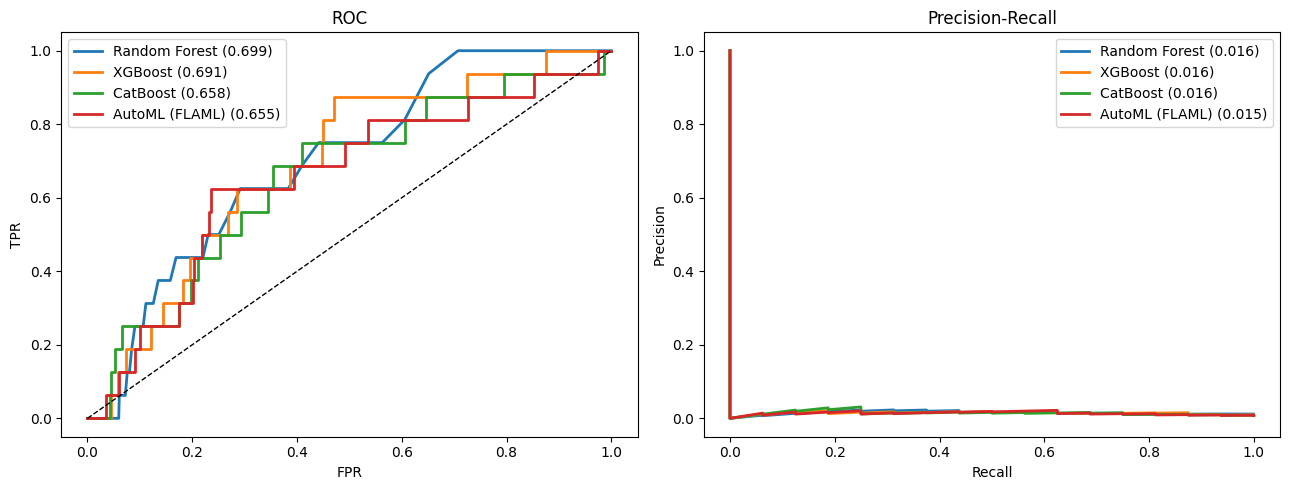

Ambang operasional (F1-optimal dari data latih): 0.9577
Test @0.50           -> Recall=0.000
Test @0.958  -> Recall=0.000 | Precision=0.000 | F1=0.000


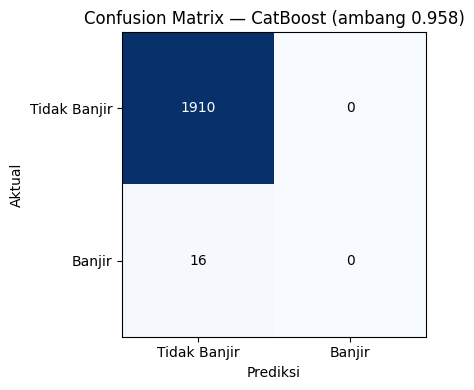

              precision    recall  f1-score   support

Tidak Banjir       0.99      1.00      1.00      1910
      Banjir       0.00      0.00      0.00        16

    accuracy                           0.99      1926
   macro avg       0.50      0.50      0.50      1926
weighted avg       0.98      0.99      0.99      1926



In [130]:
def proba(m, X):
    return np.asarray(m.predict_proba(X))[:, 1]
rows, results = {}, []
for name, m in models.items():
    p = proba(m, X_test); rows[name] = p; pred = (p >= 0.5).astype(int)
    results.append(dict(Model=name, Accuracy=accuracy_score(y_test, pred),
                        Balanced_Acc=balanced_accuracy_score(y_test, pred),
                        Precision=precision_score(y_test, pred, zero_division=0),
                        Recall=recall_score(y_test, pred, zero_division=0),
                        F1=f1_score(y_test, pred, zero_division=0),
                        AUC_ROC=roc_auc_score(y_test, p) if y_test.nunique() > 1 else np.nan,
                        AUC_PR=average_precision_score(y_test, p) if y_test.nunique() > 1 else np.nan))
res_df = pd.DataFrame(results).set_index("Model").sort_values("AUC_PR", ascending=False)
best_name = res_df.index[0]; best_model = models[best_name]
print("Model terbaik (AUC-PR):", best_name); display(res_df.round(4))

if y_test.nunique() > 1:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for name, p in rows.items():
        fpr, tpr, _ = roc_curve(y_test, p); ax[0].plot(fpr, tpr, lw=2, label=f"{name} ({roc_auc_score(y_test, p):.3f})")
        pr, rc, _ = precision_recall_curve(y_test, p); ax[1].plot(rc, pr, lw=2, label=f"{name} ({average_precision_score(y_test, p):.3f})")
    ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
    ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
    plt.tight_layout(); plt.show()

# --- Tuning ambang keputusan (PENTING untuk data banjir yang sangat langka) ---
# Pada ambang 0.5 model hampir selalu memprediksi 'tidak banjir' (Recall=0). Untuk sistem
# peringatan dini, Recall lebih penting. Ambang dipilih dari DATA LATIH (bukan test, jadi tanpa
# kebocoran test) untuk memaksimalkan F1, lalu dipakai sebagai ambang operasional di data uji.
p_tr = proba(best_model, X_train)   # X_train = fitur latih ASLI (sebelum SMOTE)
if y_train.nunique() > 1:
    pr_t, rc_t, thr_t = precision_recall_curve(y_train, p_tr)
    f1_t = 2 * pr_t * rc_t / (pr_t + rc_t + 1e-12)
    OPER_THR = float(thr_t[int(np.nanargmax(f1_t[:-1]))]) if len(thr_t) else 0.5
else:
    OPER_THR = 0.5
p_te = proba(best_model, X_test)
print(f"Ambang operasional (F1-optimal dari data latih): {OPER_THR:.4f}")
print(f"Test @0.50           -> Recall={recall_score(y_test, (p_te >= 0.5).astype(int), zero_division=0):.3f}")
print(f"Test @{OPER_THR:.3f}  -> Recall={recall_score(y_test, (p_te >= OPER_THR).astype(int), zero_division=0):.3f}"
      f" | Precision={precision_score(y_test, (p_te >= OPER_THR).astype(int), zero_division=0):.3f}"
      f" | F1={f1_score(y_test, (p_te >= OPER_THR).astype(int), zero_division=0):.3f}")

best_pred = (p_te >= OPER_THR).astype(int)
cm = confusion_matrix(y_test, best_pred)
fig, axc = plt.subplots(figsize=(4.5, 4)); axc.imshow(cm, cmap="Blues")
axc.set_xticks([0, 1]); axc.set_xticklabels(["Tidak Banjir", "Banjir"]); axc.set_yticks([0, 1]); axc.set_yticklabels(["Tidak Banjir", "Banjir"])
axc.set_xlabel("Prediksi"); axc.set_ylabel("Aktual"); axc.set_title(f"Confusion Matrix — {best_name} (ambang {OPER_THR:.3f})")
for (r, c), v in np.ndenumerate(cm):
    axc.text(c, r, str(v), ha="center", va="center", color="white" if v > cm.max()/2 else "black")
plt.tight_layout(); plt.show()
print(classification_report(y_test, best_pred, target_names=["Tidak Banjir", "Banjir"], zero_division=0))

## 12. Output prediksi: kota + kecamatan + data
**Mode time series:** model memprediksi *kapan* banjir per kota (`t+3`). Karena data cuaca tidak
punya dimensi kecamatan, kecamatan terdampak dilampirkan dari **data historis banjir BPS per
kecamatan** (sebagai prior lokasi, diurut dari yang paling sering banjir). Output: tanggal, kota,
kecamatan, jumlah banjir historis, koordinat kota, dan probabilitas prediksi.

In [131]:
if MODE == "timeseries":
    THR = OPER_THR if "OPER_THR" in dir() else 0.5   # pakai ambang operasional dari sel evaluasi
    id_cols = [c for c in info["id_cols"] if c in test_df.columns]
    pred_df = test_df[id_cols].copy()
    pred_df["flood_proba"] = proba(best_model, X_test)
    pred_df["flood_pred"] = (pred_df["flood_proba"] >= THR).astype(int)
    pred_df["flood_actual"] = y_test.values
    pred_df.to_csv(OUT_DIR / "timeseries_predictions_kota.csv", index=False)

    hot = pred_df[pred_df["flood_pred"] == 1]
    if hot.empty:
        hot = pred_df.sort_values("flood_proba", ascending=False).head(10)
        print("Tidak ada prediksi >= ambang; menampilkan 10 hari paling berisiko.")

    # Lampirkan kecamatan dari data historis BPS (clean/banjir_*.csv).
    # File ini ada di repo -> otomatis terbawa bila `git clone` (Sel 0). Kalau kecamatan NaN,
    # berarti folder clean/ tidak ikut; pastikan repo ter-clone penuh atau sertakan clean/ di ZIP.
    cand, seen, kec_frames = [], set(), []
    for root in [BASE_DIR, Path.cwd(), BASE_DIR.parent]:
        cand += [root / "clean" / "banjir_balikpapan.csv", root / "clean" / "banjir_samarinda.csv"]
    for p in cand:
        rp = Path(p).resolve()
        if rp.exists() and rp not in seen:
            seen.add(rp); kec_frames.append(pd.read_csv(rp))
    if kec_frames:
        kec = pd.concat(kec_frames, ignore_index=True).rename(columns={"kota": "city", "banjir_count": "banjir_historis"})
        out = hot.merge(kec[["city", "kecamatan", "banjir_historis"]], on="city", how="left")
        out = out.sort_values(["time", "city", "banjir_historis"], ascending=[True, True, False]).reset_index(drop=True)
    else:
        out = hot.assign(kecamatan=np.nan, banjir_historis=np.nan)
        print("clean/banjir_*.csv tidak ditemukan -> kecamatan NaN. Pastikan folder clean/ ada (clone repo penuh).")

    cols = [c for c in ["time", "city", "kecamatan", "banjir_historis", "latitude", "longitude",
                        "flood_proba", "flood_pred", "flood_actual"] if c in out.columns]
    out = out[cols]
    out.to_csv(OUT_DIR / "timeseries_predictions_kecamatan.csv", index=False)
    caught = int(((pred_df["flood_pred"] == 1) & (pred_df["flood_actual"] == 1)).sum())
    print(f"Hari diprediksi banjir: {int((pred_df['flood_pred']==1).sum())} | benar banjir (TP): {caught} dari {int(pred_df['flood_actual'].sum())} kejadian aktual")
    print(f"Output kota+kecamatan: {len(out)} baris. Contoh:")
    display(out.head(30))
    print("Tersimpan:", OUT_DIR / "timeseries_predictions_kecamatan.csv")
else:
    print("Mode geospatial: output kecamatan/koordinat berupa peta probabilitas (sel 14).")

Tidak ada prediksi >= ambang; menampilkan 10 hari paling berisiko.
Hari diprediksi banjir: 0 | benar banjir (TP): 0 dari 16 kejadian aktual
Output kota+kecamatan: 192 baris. Contoh:


,time,city,kecamatan,banjir_historis,latitude,longitude,flood_proba,flood_pred,flood_actual
0,2023-03-13,Kota Samarinda,Samarinda Ulu,8,-0.527241,117.13390,0.370224,0,0
1,2023-03-13,Kota Samarinda,Samarinda Utara,8,-0.527241,117.13390,0.370224,0,0
2,2023-03-13,Kota Samarinda,Samarinda Ulu,8,-0.527241,117.13390,0.370224,0,0
3,2023-03-13,Kota Samarinda,Samarinda Utara,8,-0.527241,117.13390,0.370224,0,0
4,2023-03-13,Kota Samarinda,Sungai Kunjang,7,-0.527241,117.13390,0.370224,0,0
5,2023-03-13,Kota Samarinda,Sungai Kunjang,7,-0.527241,117.13390,0.370224,0,0
6,2023-03-13,Kota Samarinda,Palaran,5,-0.527241,117.13390,0.370224,0,0
7,2023-03-13,Kota Samarinda,Samarinda Ilir,5,-0.527241,117.13390,0.370224,0,0
8,2023-03-13,Kota Samarinda,Loa Janan Ilir,5,-0.527241,117.13390,0.370224,0,0
9,2023-03-13,Kota Samarinda,Palaran,5,-0.527241,117.13390,0.370224,0,0


Tersimpan: /content/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/outputs/timeseries_predictions_kecamatan.csv


## 13. Feature importance & simpan hasil

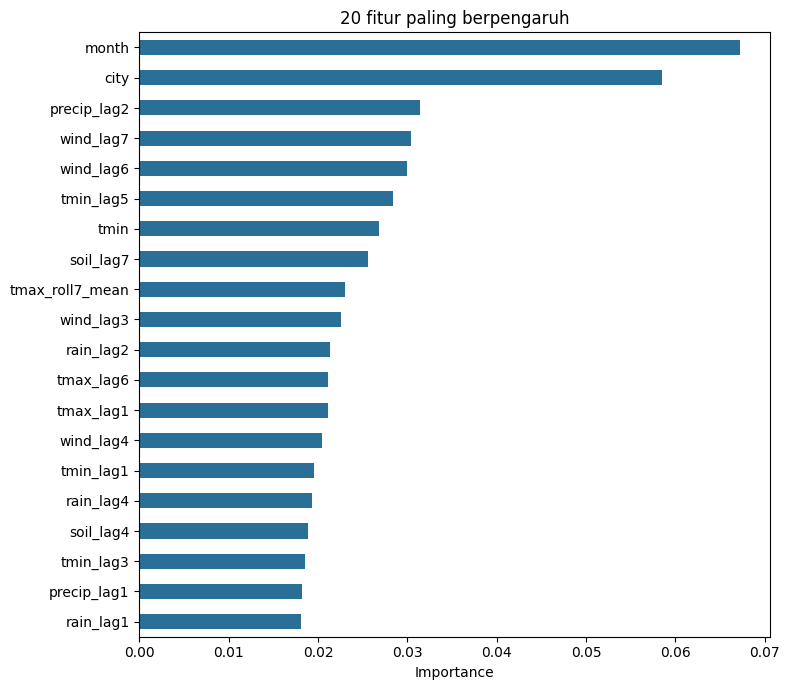

,Random Forest,XGBoost,CatBoost,AutoML (FLAML),mean
month,0.0661,0.0438,0.0873,0.0719,0.0673
city,0.0423,0.0544,0.0725,0.0648,0.0585
precip_lag2,0.0325,0.0440,0.0262,0.0229,0.0314
wind_lag7,0.0196,0.0266,0.0406,0.0349,0.0305
wind_lag6,0.0279,0.0310,0.0313,0.0296,0.0300
tmin_lag5,0.0183,0.0221,0.0357,0.0373,0.0283
tmin,0.0376,0.0250,0.0224,0.0221,0.0268
soil_lag7,0.0252,0.0266,0.0238,0.0269,0.0256
tmax_roll7_mean,0.0219,0.0445,0.0127,0.0127,0.0230
wind_lag3,0.0188,0.0244,0.0235,0.0236,0.0226


Tersimpan: /content/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/flood-bpn-smd/outputs/timeseries_model_comparison.csv


In [132]:
frames = []
for name, m in models.items():
    imp = getattr(m, "feature_importances_", None)
    if imp is None and name == "AutoML (FLAML)":
        est = getattr(getattr(m, "model", None), "estimator", None); imp = getattr(est, "feature_importances_", None)
    if imp is not None and len(imp) == X_train.shape[1]:
        frames.append(pd.Series(np.asarray(imp) / (np.sum(imp) + 1e-12), index=X_train.columns, name=name))
if frames:
    imp_df = pd.concat(frames, axis=1); imp_df["mean"] = imp_df.mean(axis=1)
    imp_df.sort_values("mean").tail(20)["mean"].plot(kind="barh", figsize=(8, 7), color="#2A6F97")
    plt.title("20 fitur paling berpengaruh"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()
    display(imp_df.sort_values("mean", ascending=False).head(15).round(4))

res_df.to_csv(OUT_DIR / f"{info['mode']}_model_comparison.csv")
print("Tersimpan:", OUT_DIR / f"{info['mode']}_model_comparison.csv")

## 14. (Khusus geospasial) Peta probabilitas banjir per kota
Hanya berjalan bila `MODE == "geospatial"`. Memprediksi probabilitas tiap sel grid DEM lalu
menyimpan GeoTIFF + PNG.

In [133]:
if MODE == "geospatial":
    for name, lyr in CITY_LAYERS.items():
        dem, slope, tr = lyr["dem"], lyr["slope"], lyr["transform"]
        rivers, roads, landcover, desakel = lyr["rivers"], lyr["roads"], lyr["landcover"], lyr["desakel"]
        H, W = dem.shape; px = abs(tr.a)
        rmask = rasterize(((g, 1) for g in rivers.geometry), out_shape=(H, W), transform=tr, fill=0, all_touched=True)
        dmask = rasterize(((g, 1) for g in roads.geometry), out_shape=(H, W), transform=tr, fill=0, all_touched=True)
        grid = pd.DataFrame({"elevation": dem.ravel(), "slope": slope.ravel(),
            "dist_river": (distance_transform_edt(rmask == 0) * px).ravel(),
            "dist_road": (distance_transform_edt(dmask == 0) * px).ravel(),
            "pop_density": rasterize(((g, float(v)) for g, v in zip(desakel.geometry, desakel["pop_density"]) if pd.notna(v)),
                                     out_shape=(H, W), transform=tr, fill=np.nan, dtype="float32").ravel(),
            "landcover": rasterize(((g, LC_MAP.get(str(v), -1)) for g, v in zip(landcover.geometry, landcover[LC_CLASS_COL])),
                                   out_shape=(H, W), transform=tr, fill=-1, dtype="float32").ravel().astype(int)})
        valid = grid[num_cols].notna().all(axis=1).values; prob = np.full(len(grid), np.nan)
        if valid.sum() > 0:
            prob[valid] = proba(best_model, transform(grid[valid]))
        pmap = prob.reshape(H, W); tif = OUT_DIR / f"flood_probability_{name}.tif"
        with rasterio.open(tif, "w", driver="GTiff", height=H, width=W, count=1, dtype="float32",
                           crs=UTM_CRS, transform=tr, nodata=np.nan) as dst:
            dst.write(pmap.astype("float32"), 1)
        plt.figure(figsize=(8, 8)); im = plt.imshow(pmap, cmap="turbo", vmin=0, vmax=1)
        plt.colorbar(im, label="Probabilitas banjir"); plt.title(f"Peta Probabilitas — {name} ({best_name})"); plt.axis("off")
        plt.savefig(OUT_DIR / f"flood_probability_{name}.png", dpi=150, bbox_inches="tight"); plt.show()
        print("Tersimpan peta:", name)
else:
    print("Lewati: peta probabilitas hanya untuk MODE geospatial.")

Lewati: peta probabilitas hanya untuk MODE geospatial.


---
## Catatan metodologi (untuk laporan/sidang)
- Data cuaca harian → **lag feature** t-1..t-7 + **akumulasi** (hujan 3/7/14 hari, dll); target = banjir **t+3**.
- **Klasifikasi biner** atas data **time series** (Time Series Classification), bukan forecasting kontinu.
- Split **berbasis waktu** (time series) mencegah kebocoran masa depan; **imbalance** ditangani hanya di
  data latih (SMOTE/class weight) **setelah** split.
- `latitude`/`longitude` **tidak ditransformasi** — dipakai sebagai info lokasi & dibawa ke output prediksi.
- **Output kecamatan (hybrid):** model memprediksi *kapan* banjir per kota; kecamatan terdampak dilampirkan
  dari **data historis banjir BPS per kecamatan** sebagai prior lokasi (data cuaca tidak punya dimensi kecamatan).
- Metrik utama: **Recall** & **AUC-PR** (lebih relevan dari accuracy untuk data sangat timpang).
- Mode **geospasial** (opsional, bila ZIP DEM+RBI di-upload): 6 conditioning factor + titik *terrain-constrained*
  → peta probabilitas banjir per kota.